# Lab 10
### Perceptrons

#### Esraaj Sarkar Gupta 
#### 5th April 2026

In [5]:
"""
Script to build and train a single perceptron.

Author: Ersaaj Sarkar Gupta
Date: 2024-06-01
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# ---- Generate Synthetic Data ---- #
NUMBER_OF_SAMPLES : int = 500

distribution_one : np.ndarray = np.zeros(int(NUMBER_OF_SAMPLES/2))
distribution_two : np.ndarray = np.zeros(int(NUMBER_OF_SAMPLES/2))

# Define Parameters
mu_one = np.array([2,2])
mu_two = np.array([5, 5])

sigma_one = np.array([
    [0.9, -0.0255],
    [-0.0255, 0.9]
])

sigma_two = np.array([
    [0.5, 0],
    [0, 0.3]
])

# Using Gaussian distributions
np.random.seed(0)

distribution_one = np.random.multivariate_normal(
    mu_one,
    sigma_one,
    int(NUMBER_OF_SAMPLES/2)
)

distribution_two = np.random.multivariate_normal(
    mu_two,
    sigma_two,
    int(NUMBER_OF_SAMPLES/2)
)

# Generate labels for synthetically generated data
labels = np.concatenate([
    np.zeros(int(NUMBER_OF_SAMPLES/2)),
    np.ones(int(NUMBER_OF_SAMPLES/2))
])

# Create a dataset with synthetically generated data
values : np.ndarray = np.concatenate([
    distribution_one,
    distribution_two
])

df = pd.DataFrame({
    "Distribution X": values[:, 0],
    "Distribution Y": values[:, 1],
    "Label": labels
})

print("Synthetic Data Dataset: ") 
display(df)

# Include bias term for X
X = np.hstack((
    np.ones((NUMBER_OF_SAMPLES, 1)),
    values
))

# ---- Create Train-Test Splits ---- #
X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels, #y
    test_size = 0.2,
    random_state = 0,
    stratify = labels
)

# ---- Build the Perceptron ---- #

class Perceptron():
    def __init__(self, X, y, learning_rate=0.1, max_epochs=1000):
        self.X = X
        self.y = y
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.weights = 0

    def step_activation(self, x : float):
        return 1 if x >= 0 else 0

    def train(self):
        """
        Trains the perceptron model.
        """
        weights = np.zeros(self.X.shape[1])

        for epoch in range(self.max_epochs):
            errors_counter : int = 0
            for i in range(len(self.X)):
                # Compute the dot product
                linear_output = np.dot(self.X[i], weights)

                # Apply activation function
                y_pred = self.step_activation(linear_output)

                # Compute error
                error = self.y[i] - y_pred

                if error != 0:
                    """
                    Update rule used:
                    W = W + (learning_rate * error * Input)
                    """
                    weights += self.learning_rate * error * self.X[i]
                    errors_counter += 1 

            if errors_counter == 0:
                print(f"Model converged perfectly at epoch {epoch}. Stopping early...")
                break
        
        self.weights = weights
        return weights
    
# Create the perceptron and train it
myPerceptron = Perceptron(X_train, y_train)
trained_weights = myPerceptron.train()

print("\nFinal Trained Weights:")
print(f"Bias Weight: {trained_weights[0]:.4f}")
print(f"Feature X Weight: {trained_weights[1]:.4f}")
print(f"Feature Y Weight: {trained_weights[2]:.4f}")

Synthetic Data Dataset: 


,Distribution X,Distribution Y,Label
0,1.064594,3.464613,0.0
1,2.815994,4.147582,0.0
2,0.083356,2.624196,0.0
3,1.253611,2.546220,0.0
4,2.341723,2.201292,0.0
...,...,...,...
495,5.311857,5.097929,1.0
496,4.434723,5.131885,1.0
497,5.204439,5.226139,1.0
498,4.859711,5.051591,1.0


Model converged perfectly at epoch 1. Stopping early...

Final Trained Weights:
Bias Weight: -1.4000
Feature X Weight: 0.1731
Feature Y Weight: 0.2186



Beginning evaluation on the test split...


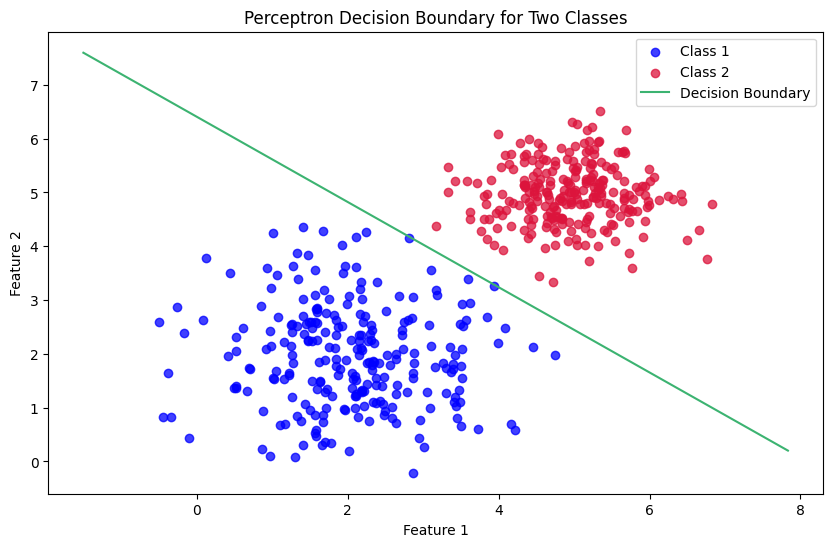

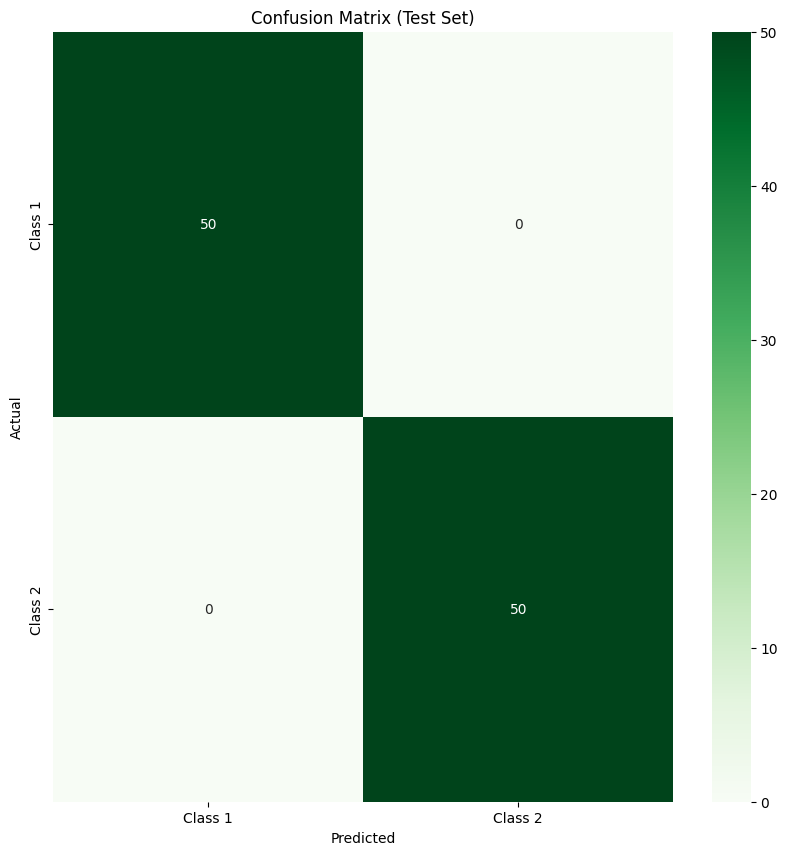

In [ ]:
"""
Script for testing the perceptron trained in the previous block.

Author: Esraaj Sarkar Gupta
Date: 5th April 2026
""" 

# ---- Visualising Results ---- #
print("\nBeginning evaluation on the test split...")

y_pred_test = []

for i in range(len(X_test)):
    # Compute the dot-product
    linear_output = np.dot(X_test[i], myPerceptron.weights)
    
    # Pass through the step activation function
    prediction = 1 if linear_output >= 0 else 0
    y_pred_test.append(prediction)

# Plot the decision boundary
plt.figure(figsize=(20,10))

# Plotting the original data points
plt.scatter(
    X[labels == 0][:,1],
    X[labels == 0][:,2],
    color="Blue",
    label="Class 1",
    alpha=0.75
)

plt.scatter(
    X[labels == 1][:,1],
    X[labels == 1][:,2],
    color="crimson",
    label="Class 2",
    alpha=0.75
)

# Boundary Line
w0, w1, w2 = trained_weights

x_values = np.array([np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1])
y_values = -(w1 / w2) * x_values - (w0 / w2)

plt.plot(x_values, y_values, color='mediumseagreen', label='Decision Boundary')

plt.title('Perceptron Decision Boundary for Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# ---- Plot the Confusion Matrix ---- #
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Class 1', 'Class 2'], 
            yticklabels=['Class 1', 'Class 2'])

plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Report

#### Questioon 1
One may draw paralles from biological neural networks to artificial neural networks. The neurons themselves correspond to nodes. The biological synapses correspond to the connection weights and the firing of an action potential corresponds to the activation function output.

#### Question 2
The McCullouch-Pitts Neuron was the earliest mathematical model of a biological neuron. This summed binary inouts and had a binary signal output if a fixed threshold was reached. The limitations this model suffered from was that there was no learning mechanism (weights and biases), and was capable of only processing strictly binary input instead of continuous data.

#### Question 3
A perceptronm learns through an iterative error-correction process. The perceptron computes a weighted sum of its input (the dot product step in this program), passes the result through an activation function to make a prediction, and compares the prediction to the actual labels of the training data to estimate the error. The weights are then updated propotionately to the error and the learning rate.

#### Question 4
Here are three examples of activation functions.
* Sigmoid function. Range: (0, 1)
* Hyperbolic tangent function `tanh()`. Range: (-1, 1)
* Rectified Linear Unit function (ReLU Function). Range: [0 , $\infty$)

#### Question 5
The classical perceptron is a linear classifier. Wheras the XOR Problem is not a linearly separable problem. Thus, a single perceptron is incapable of solving the XOR Problem. One may solve the XOR Problem without projecting the data into a higher dimensional space by adding a hidden layer of neurons (creating a mutlti-layer perceptron), which allows the network to combine multiple linear boundaries to for, a non-linear decision region.
